In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import json
import plotly.express as px
import seaborn as sns
from IPython.display import display
import os



#📌 Extracción

In [2]:
datos_url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [3]:
datos_brutos = pd.read_json(datos_url)
datos_brutos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Observacion.

Al mostar la tabla de datos bvemos que tiene estrictura anidada, por lo que hay que normalizar el archivo

#🔧 Transformación

Prestar atención a valores ausentes, duplicados, errores de formato e inconsistencias en las categorías. Este proceso es esencial para asegurar que los datos estén listos para las siguientes etapas.

In [4]:
# visualizamos un elemento para explorar el numero de atributos en cada colomna
for i, j in datos_brutos.iloc[0].items():
  print(i,'\n',j)

customerID 
 0002-ORFBO
Churn 
 No
customer 
 {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}
phone 
 {'PhoneService': 'Yes', 'MultipleLines': 'No'}
internet 
 {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}
account 
 {'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}


In [5]:
datos_diccionario = datos_brutos.to_dict(orient='records')

In [6]:
# mo vemos que algunos datos aun tienen un nivel extra de anidado en el diccionario, usaremos como parametro al nomalizar max_level = 2
datos_normalizados = pd.json_normalize(datos_diccionario, max_level=2)
datos_normalizados.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
#generamos nuevo diccionario para renombrar las columnas,eliminando prefijos derivados de la normalizacion
nuevos_nombres = {x : x.replace('customer.', '').replace('internet.', '').replace('account.', '').replace('.', ' ') for x in datos_normalizados.columns}
nuevos_nombres

{'customerID': 'customerID',
 'Churn': 'Churn',
 'customer.gender': 'gender',
 'customer.SeniorCitizen': 'SeniorCitizen',
 'customer.Partner': 'Partner',
 'customer.Dependents': 'Dependents',
 'customer.tenure': 'tenure',
 'phone.PhoneService': 'phone PhoneService',
 'phone.MultipleLines': 'phone MultipleLines',
 'internet.InternetService': 'InternetService',
 'internet.OnlineSecurity': 'OnlineSecurity',
 'internet.OnlineBackup': 'OnlineBackup',
 'internet.DeviceProtection': 'DeviceProtection',
 'internet.TechSupport': 'TechSupport',
 'internet.StreamingTV': 'StreamingTV',
 'internet.StreamingMovies': 'StreamingMovies',
 'account.Contract': 'Contract',
 'account.PaperlessBilling': 'PaperlessBilling',
 'account.PaymentMethod': 'PaymentMethod',
 'account.Charges.Monthly': 'Charges Monthly',
 'account.Charges.Total': 'Charges Total'}

In [8]:
# renombramos
datos_normalizados = datos_normalizados.rename(columns=nuevos_nombres)
datos_normalizados.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,phone PhoneService,phone MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges Monthly,Charges Total
1199,1709-EJDOX,No,Female,0,Yes,Yes,47,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.75,948.9
1607,2277-AXSDC,No,Female,0,No,No,32,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.75,624.15
4952,6765-MBQNU,No,Female,0,Yes,No,26,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,26.00,684.05
4982,6817-WTYHE,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),44.90,111.05
3818,5226-NOZFC,No,Male,0,No,No,26,Yes,No,Fiber optic,...,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,85.75,2146.5
1446,2077-DDHJK,No,Female,0,Yes,No,68,Yes,Yes,DSL,...,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),70.90,4911.35
1624,2307-FYNNL,No,Male,1,No,No,65,Yes,Yes,Fiber optic,...,No,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,109.05,7108.2
3184,4446-BZKHU,Yes,Male,0,Yes,No,61,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.55,6281.45
4568,6259-WJQLC,No,Male,1,No,No,32,Yes,Yes,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),81.10,2619.25
6743,9290-SHCMB,No,Female,1,No,No,13,Yes,No,Fiber optic,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.85,1235.55


In [9]:
# buscamos por datos faltantes
print('Conteo de datos NA\n',datos_normalizados.isna().sum(), '\n', '='*50)
print('Conteo de datos null\n', datos_normalizados.isnull().sum(), '\n', '='*50)
print('Conteo de datos faltantes o en blanco', (datos_normalizados.map(lambda x: str(x).strip())=='').sum(), '\n', '='*50)


Conteo de datos NA
 customerID             0
Churn                  0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
phone PhoneService     0
phone MultipleLines    0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
Charges Monthly        0
Charges Total          0
dtype: int64 
Conteo de datos null
 customerID             0
Churn                  0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
phone PhoneService     0
phone MultipleLines    0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract           

In [10]:
# Eliminamos los datos donde Churn tiene campo en blanco o faltante
indices_datos_vacios_Churn = datos_normalizados[(datos_normalizados['Churn'].map(lambda x: str(x).strip())=='')].index
datos_normalizados.drop(indices_datos_vacios_Churn, inplace=True)

In [11]:
# Observamos los datos donde Charges Total tiene campo en blanco o faltante
indices_datos_vacios_ChargesTotal = datos_normalizados[(datos_normalizados['Charges Total'].map(lambda x: str(x).strip())=='')].index
datos_normalizados.loc[indices_datos_vacios_ChargesTotal]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,phone PhoneService,phone MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges Monthly,Charges Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


El campo de "Charges Total" esta en blanco en aquellos clientes que tienen un "tenure" = 0, por lo que aun no se les ha cobrado, por lo que es posible indicar que el campo faltantes es equivalente a un Cero.
Tambien cambniamos todos los valores a flotante

In [12]:
datos_normalizados.loc[indices_datos_vacios_ChargesTotal , 'Charges Total'] = 0
datos_normalizados.loc[indices_datos_vacios_ChargesTotal]
datos_normalizados['Charges Total'] = datos_normalizados['Charges Total'].apply(lambda x: float(x) )

In [13]:
datos_normalizados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   object 
 1   Churn                7043 non-null   object 
 2   gender               7043 non-null   object 
 3   SeniorCitizen        7043 non-null   int64  
 4   Partner              7043 non-null   object 
 5   Dependents           7043 non-null   object 
 6   tenure               7043 non-null   int64  
 7   phone PhoneService   7043 non-null   object 
 8   phone MultipleLines  7043 non-null   object 
 9   InternetService      7043 non-null   object 
 10  OnlineSecurity       7043 non-null   object 
 11  OnlineBackup         7043 non-null   object 
 12  DeviceProtection     7043 non-null   object 
 13  TechSupport          7043 non-null   object 
 14  StreamingTV          7043 non-null   object 
 15  StreamingMovies      7043 non-null   object

In [14]:
# revisando consistencia de datos en columnas tipo objeto
for col, name  in enumerate(datos_normalizados.columns):
  if datos_normalizados[name].dtype == 'object':
    print(name, '\n\tvalues:\n\t'  , datos_normalizados[name].unique())

customerID 
	values:
	 ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn 
	values:
	 ['No' 'Yes']
gender 
	values:
	 ['Female' 'Male']
Partner 
	values:
	 ['Yes' 'No']
Dependents 
	values:
	 ['Yes' 'No']
phone PhoneService 
	values:
	 ['Yes' 'No']
phone MultipleLines 
	values:
	 ['No' 'Yes' 'No phone service']
InternetService 
	values:
	 ['DSL' 'Fiber optic' 'No']
OnlineSecurity 
	values:
	 ['No' 'Yes' 'No internet service']
OnlineBackup 
	values:
	 ['Yes' 'No' 'No internet service']
DeviceProtection 
	values:
	 ['No' 'Yes' 'No internet service']
TechSupport 
	values:
	 ['Yes' 'No' 'No internet service']
StreamingTV 
	values:
	 ['Yes' 'No' 'No internet service']
StreamingMovies 
	values:
	 ['No' 'Yes' 'No internet service']
Contract 
	values:
	 ['One year' 'Month-to-month' 'Two year']
PaperlessBilling 
	values:
	 ['Yes' 'No']
PaymentMethod 
	values:
	 ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [15]:
# Calculo de cuota diaria en lugar de mensual (30 dias)
dia_en_mes = 30
datos_normalizados['Charges Daily'] = datos_normalizados['Charges Monthly'] / dia_en_mes
# Traduccion de datos a español, y los valores de Si/No los volvemos 1 y 0 respectivamente
traduccion_columnas = {
    'customerID': 'ID Cliente',
    'Churn': 'Abandono',
    'gender': 'Género',
    'SeniorCitizen': 'Adulto mayor',
    'Partner': 'Con pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antigüedad',
    'phone PhoneService': 'Servicio Telefónico',
    'phone MultipleLines': 'Líneas Múltiples',
    'InternetService': 'Servicio de Internet',
    'OnlineSecurity': 'Seguridad Online',
    'OnlineBackup': 'Copia de Seguridad Online',
    'DeviceProtection': 'Protección Dispositivo',
    'TechSupport': 'Soporte Técnico',
    'StreamingTV': 'Streaming TV',
    'StreamingMovies': 'Streaming Películas',
    'Contract': 'Tipo de contrato',
    'PaperlessBilling': 'Facturación Sin Papel',
    'PaymentMethod': 'Método de Pago',
    'Charges Monthly': 'Cargos Mensuales',
    'Charges Total': 'Cargos Totales',
    'Charges Daily': 'Cargos Diarios',
}
traduccion_datos = {
    'Yes': 1,
    'No': 0,
    'No internet service': 'Sin servicio de Internet',
    'No phone service': 'Sin servicio telefónico',
    'Month-to-month': 'Mensual',
    'One year': 'Anual',
    'Two year': 'Semestral',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Electronic check': 'Cheque electrónico',
    'Mailed check': 'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)',
    'Fiber optic': 'Fibra óptica',
    'DSL': 'DSL',
    'Male': 'Masculino',
    'Female': 'Femenino',
}

In [16]:
datos = datos_normalizados.rename(columns=traduccion_columnas)
datos = datos.replace(traduccion_datos)
#para el caso particular de 'Servicio de internet' se conserva el 'No'
datos['Servicio de Internet'] = datos['Servicio de Internet'].replace(0, 'No')
datos.head()

/tmp/ipykernel_239/3213813126.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos = datos.replace(traduccion_datos)


,ID Cliente,Abandono,Género,Adulto mayor,Con pareja,Dependientes,Antigüedad,Servicio Telefónico,Líneas Múltiples,Servicio de Internet,...,Protección Dispositivo,Soporte Técnico,Streaming TV,Streaming Películas,Tipo de contrato,Facturación Sin Papel,Método de Pago,Cargos Mensuales,Cargos Totales,Cargos Diarios
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Cheque por correo,65.6,593.30,2.186667
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensual,0,Cheque por correo,59.9,542.40,1.996667
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra óptica,...,1,0,0,0,Mensual,1,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra óptica,...,1,0,1,1,Mensual,1,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fibra óptica,...,0,1,1,0,Mensual,1,Cheque por correo,83.9,267.40,2.796667


In [17]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID Cliente                 7043 non-null   object 
 1   Abandono                   7043 non-null   int64  
 2   Género                     7043 non-null   object 
 3   Adulto mayor               7043 non-null   int64  
 4   Con pareja                 7043 non-null   int64  
 5   Dependientes               7043 non-null   int64  
 6   Antigüedad                 7043 non-null   int64  
 7   Servicio Telefónico        7043 non-null   int64  
 8   Líneas Múltiples           7043 non-null   object 
 9   Servicio de Internet       7043 non-null   object 
 10  Seguridad Online           7043 non-null   object 
 11  Copia de Seguridad Online  7043 non-null   object 
 12  Protección Dispositivo     7043 non-null   object 
 13  Soporte Técnico            7043 non-null   object 
 1

In [18]:
print([nombre for nombre, tipo in datos.dtypes.items() if tipo is np.dtype('O')])
print([nombre for nombre, tipo in datos.dtypes.items() if tipo is np.dtype('int64')])
print([nombre for nombre, tipo in datos.dtypes.items() if tipo is np.dtype('float64')])

['ID Cliente', 'Género', 'Líneas Múltiples', 'Servicio de Internet', 'Seguridad Online', 'Copia de Seguridad Online', 'Protección Dispositivo', 'Soporte Técnico', 'Streaming TV', 'Streaming Películas', 'Tipo de contrato', 'Método de Pago']
['Abandono', 'Adulto mayor', 'Con pareja', 'Dependientes', 'Antigüedad', 'Servicio Telefónico', 'Facturación Sin Papel']
['Cargos Mensuales', 'Cargos Totales', 'Cargos Diarios']


In [19]:
# Separamos columnas de acuerdo al tipo de dato
# Genero estaba en categorica y la pasamos a binaria, y la antiguedad la pasamos a numerica
columnas_categoricas = ['ID Cliente', 'Líneas Múltiples', 'Servicio de Internet', 'Seguridad Online', 'Copia de Seguridad Online', 'Protección Dispositivo', 'Soporte Técnico', 'Streaming TV', 'Streaming Películas', 'Tipo de contrato', 'Método de Pago']
columnas_binarias = ['Abandono', 'Adulto mayor', 'Con pareja', 'Género', 'Dependientes', 'Servicio Telefónico', 'Facturación Sin Papel']
columnas_numericas = ['Cargos Mensuales', 'Cargos Totales', 'Cargos Diarios', 'Antigüedad']

In [20]:
# Columnas binaria, asignamos valores de Si o No en lugar de 1 y 0 respectivamente
datos[columnas_binarias] = datos[columnas_binarias].replace({1:'Sí', 0:'No'})


#📊 Carga y análisis

### Analisis descritivo


In [21]:
#Analisis descritivo
datos.describe()

,Antigüedad,Cargos Mensuales,Cargos Totales,Cargos Diarios
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


### Distribución de evasión

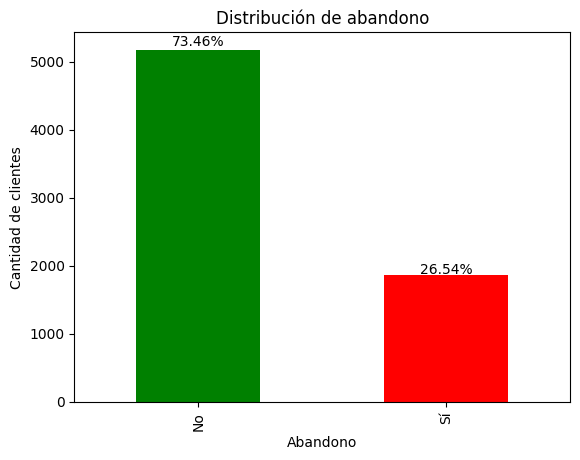

In [22]:
abandonaron = datos['Abandono'].value_counts()
abandonaron_porcentage = datos['Abandono'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
abandonaron.plot(kind = 'bar' , color = ['g', 'r'], ax=ax)
[ax.text(indice, abandonaron[nombre]*1.01, f'{valor:.2f}%', ha = 'center') for indice, (nombre, valor) in enumerate(abandonaron_porcentage.items())]
ax.set_title('Distribución de abandono')
ax.set_xlabel('Abandono')
ax.set_ylabel('Cantidad de clientes')

#para guardar, primero creamos directorio en caso de que no este.
if not os.path.exists('./Imagenes'):
    os.makedirs('./Imagenes')
fig.savefig('./Imagenes/Distribucion de abandono.jpeg')


### Datos binarios (dos valores)

In [23]:
 [display(px.histogram(datos, x = columna, color = 'Abandono', text_auto = True, barmode= 'group', barnorm='percent')) for columna in columnas_binarias if columna != 'Abandono']

[None, None, None, None, None, None]

In [24]:
#guradamos los graficos
[display(px.histogram(datos, x = columna, color = 'Abandono', text_auto = True, barmode= 'group', barnorm='percent').write_html(f'./Imagenes/Abandono vs {columna}.html')) for columna in columnas_binarias if columna != 'Abandono']

None

None

None

None

None

None

[None, None, None, None, None, None]

#### Observaciones

De las diferentes categorias con datos binario, quienes presentan una mayor tasa de abandano ( 10% mas que el complemento en la categoria) son los adultos mayores, los que NO tienen dependientes economicos, los que facturan sin pape, y los que no cuentan con pareja.



Agrupamos los valores por Abandono, y luego por caracteristica binara para identificar que caracteristicas comparten los que contribuyen con una mayor porcentaje de abandono.

In [25]:
abandono_binario = (datos.groupby('Abandono')[columnas_binarias].value_counts(normalize=True) * 100)
abandono_binario

Abandono  Adulto mayor  Con pareja  Género     Dependientes  Servicio Telefónico  Facturación Sin Papel
No        No            No          Masculino  No            Sí                   No                       8.368767
                                                                                  Sí                       8.368767
                                    Femenino   No            Sí                   Sí                       8.252802
                                                                                  No                       7.344414
                        Sí          Masculino  Sí            Sí                   No                       6.706610
                                                                                                             ...   
Sí        No            No          Femenino   Sí            No                   Sí                       0.053505
          Sí            No          Femenino   Sí            Sí                   Sí                       0.053505
                                    Masculino  Sí            Sí                   Sí                       0.053505
                        Sí          Femenino   No            No                   No                       0.053505
                                    Masculino  Sí            No                   No                       0.053505
Name: proportion, Length: 112, dtype: float64

Filtramos los que Si abandonaron, y ordemaos los valores de mayor a menor

In [26]:
abandono_binario = abandono_binario['Sí'].sort_values(ascending=False)

abandono_binario.head(10)

Adulto mayor  Con pareja  Género     Dependientes  Servicio Telefónico  Facturación Sin Papel
No            No          Femenino   No            Sí                   Sí                       15.195292
                          Masculino  No            Sí                   Sí                       14.446228
Sí            No          Femenino   No            Sí                   Sí                        6.474050
No            No          Femenino   No            Sí                   No                        5.992509
                          Masculino  No            Sí                   No                        5.671482
              Sí          Masculino  No            Sí                   Sí                        5.029428
Sí            No          Masculino  No            Sí                   Sí                        4.708400
              Sí          Masculino  No            Sí                   Sí                        4.440877
No            Sí          Femenino   Sí            Sí                   Sí                        4.333868
                                     No            Sí                   Sí                        4.012841
Name: proportion, dtype: float64

In [27]:
print(f'Hay un total de {abandono_binario.size} grupos')
# Arbitrariamente, se consideraran el 10% de los grupos con mayor porcentaje de abandono

Hay un total de 54 grupos


In [28]:
porcentaje_5_grupos_de_mas_abandono_binario = abandono_binario.head(5).sum()
print(f'el 10% de las categorias binarias de mayor abandono, tienen un porcentaje acumulado del {porcentaje_5_grupos_de_mas_abandono_binario:.2f}%')

el 10% de las categorias binarias de mayor abandono, tienen un porcentaje acumulado del 47.78%


#### Observaciones

Hay dos grupos grandes que cubren aprox el 30% de abandono: Adultos No mayores,sin pareja yque tienen servicio telefonico y facturacion sin papel.

Lo que comparten las categorias que acumulan el 47% es que Todas tiene servicio telefonico, y en su mayoria no tienen dependientes y si tienen la facturacion sin papel.

Estos son los grupos a los que se debe de implementar una mejor estrategia para su retención.




### Datos categoricos (no numericos)

In [29]:
[display(px.histogram(datos, x = columna, color = 'Abandono', text_auto = True, barmode= 'group', barnorm='percent')) for columna in columnas_categoricas if columna != 'ID Cliente']

[None, None, None, None, None, None, None, None, None, None]

In [30]:
[display(px.histogram(datos, x = columna, color = 'Abandono', text_auto = True, barmode= 'group', barnorm='percent').write_html(f'./Imagenes/Abandono vs {columna}.html')) for columna in columnas_categoricas if columna != 'ID Cliente']

None

None

None

None

None

...

None

None

None

None

[None, None, None, None, None, None, None, None, None, None]

#### Observaciones

De las diferentes categorias con datos categoricos, quienes presentan una mayor tasa de abandano ( 10% mas que el complemento en la categoria) son los que pagan con cheque electrónico, los que tienen contrato mensual, los que cuentan con servicio de fibra optica, y en gral los que rechazan los servicios complementarios como soporte tecnico, proteccion de dispositivo, copia de seguridad online, seguridad online.



Agrupamos los valores por Abandono, y luego por caracteristica categorica (excluyendo el ID Cliente), para identificar que caracteristicas comparten los que contribuyen con una mayor porcentaje de abandono.

In [31]:
abandono_categorico = (datos.groupby('Abandono')[[columna for columna in columnas_categoricas if columna != 'ID Cliente']].value_counts(normalize=True) * 100)
abandono_categorico = abandono_categorico['Sí'].sort_values(ascending=False)
abandono_categorico.head(10)


Líneas Múltiples  Servicio de Internet  Seguridad Online          Copia de Seguridad Online  Protección Dispositivo    Soporte Técnico           Streaming TV              Streaming Películas       Tipo de contrato  Método de Pago    
0                 Fibra óptica          0                         0                          0                         0                         0                         0                         Mensual           Cheque electrónico    4.868914
1                 Fibra óptica          0                         0                          0                         0                         0                         0                         Mensual           Cheque electrónico    3.477796
0                 No                    Sin servicio de Internet  Sin servicio de Internet   Sin servicio de Internet  Sin servicio de Internet  Sin servicio de Internet  Sin servicio de Internet  Mensual           Cheque por correo     3.477796
1                 Fibra óptica          0                         0                          0                         0                         1                         1                         Mensual           Cheque electrónico    2.835741
                                                                                             1                         0                         1                         1                         Mensual           Cheque electrónico    2.140182
                                                                                             0                         0                         0                         1                         Mensual           Cheque electrónico    2.140182
0                 Fibra óptica          0                         0                          0                         0                         1                         0                         Mensual           Cheque electrónico    2.140182
1                 Fibra óptica          0                         1                          1                         0                         1                         1                         Mensual           Cheque electrónico    1.712146
0                 Fibra óptica          0                         0                          0                         0                         1                         1                         Mensual           Cheque electrónico    1.712146
                                                                                                                                                 0                         1                         Mensual           Cheque electrónico    1.712146
Name: proportion, dtype: float64

In [32]:
print(f'Hay un total de {abandono_categorico.size} grupos')
# de nuevo tomando el 10% de los grupos de mayor abandono

Hay un total de 586 grupos


In [33]:
abandono_categorico.head(20)

Líneas Múltiples         Servicio de Internet  Seguridad Online          Copia de Seguridad Online  Protección Dispositivo    Soporte Técnico           Streaming TV              Streaming Películas       Tipo de contrato  Método de Pago                     
0                        Fibra óptica          0                         0                          0                         0                         0                         0                         Mensual           Cheque electrónico                     4.868914
1                        Fibra óptica          0                         0                          0                         0                         0                         0                         Mensual           Cheque electrónico                     3.477796
0                        No                    Sin servicio de Internet  Sin servicio de Internet   Sin servicio de Internet  Sin servicio de Internet  Sin servicio de Internet  Sin servicio de Internet  Mensual           Cheque por correo                      3.477796
1                        Fibra óptica          0                         0                          0                         0                         1                         1                         Mensual           Cheque electrónico                     2.835741
                                                                                                    1                         0                         1                         1                         Mensual           Cheque electrónico                     2.140182
                                                                                                    0                         0                         0                         1                         Mensual           Cheque electrónico                     2.140182
0                        Fibra óptica          0                         0                          0                         0                         1                         0                         Mensual           Cheque electrónico                     2.140182
1                        Fibra óptica          0                         1                          1                         0                         1                         1                         Mensual           Cheque electrónico                     1.712146
0                        Fibra óptica          0                         0                          0                         0                         1                         1                         Mensual           Cheque electrónico                     1.712146
                                                                                                                                                        0                         1                         Mensual           Cheque electrónico                     1.712146
                         DSL                   0                         0                          0                         0                         0                         0                         Mensual           Cheque electrónico                     1.605136
1                        Fibra óptica          0                         1                          0                         0                         1                         1                         Mensual           Cheque electrónico                     1.498127
0                        DSL                   0                         0                          0                         0                         0                         0                         Mensual           Cheque por correo                      1.498127
1                        Fibra óptica          0                         0                          0                         0                         1                         0                         Mensual           Cheque ele

In [34]:
porcentaje_59_grupos_de_mas_abandono_categorico = abandono_categorico.head(59).sum()
print(f'en el 10% categorias categoricas de mayor abandono se, se tiene un porcentaje acumulado del {porcentaje_59_grupos_de_mas_abandono_categorico:.2f}%')

en el 10% categorias categoricas de mayor abandono se, se tiene un porcentaje acumulado del 55.81%


#### Observaciones

Debido a que al ser mas las variables categoricas, y que tienen mas valores para las variables, se cuentan con mas categorias, lo cual provoca que el porcentaje de distribuya , generando valores menores. Sin embargo, vemos que el porcentaje acumulado de abando en el 10% de categorias, disminuyo considerablemente con respecto a las categorias binarias.
En este caso se observa que las caracteristicas que muestran un porcentaje mayor al 1% de abandono, tienen en comun lo siguiente. Todas tienen pago por cheque electronico, contrato mensual y en su mayoria son con fibra optica, y no cuentan con los servicios de protecion añadido. por lo que estos son los puntos principales a tratar de enfocarse.

### Datos numericos

In [35]:
[display(px.histogram(datos, x = columna, color = 'Abandono', text_auto = True, barmode= 'group', barnorm='percent')) for columna in columnas_numericas]

[None, None, None, None]

Cmo se tiene muchas columnas, es mejor realizar un grafico que no este normalizado por valor, para vtener una mejor perspectiva de los numeros absolutos de abandono

In [36]:
[display(px.histogram(datos, x = columna, color = 'Abandono', text_auto = True)) for columna in columnas_numericas]

[None, None, None, None]

In [37]:
[display(px.histogram(datos, x = columna, color = 'Abandono', text_auto = True).write_html(f'./Imagenes/Abandono vs {columna}.html')) for columna in columnas_numericas]

None

None

None

None

[None, None, None, None]

#### Observaciones

Se observa que el abandono aumenta en los usuarios con una menor antiguedad, incluso se ve que abandonan incluso antes de la primera mensualidad, ya que se el maximo de abandono relativo en las personas que tienen un cargo total de \$0.
Se observsa que los clientes que tienen un cargo mensual superior a los \$60, suelen ser propensos al abandono, por lo que e sun punto a mejorar.


In [38]:
abandono_numerico = (datos.groupby('Abandono')[['Cargos Diarios',	'Antigüedad'	]].value_counts(normalize=True) * 100)

In [39]:
datos[columnas_numericas].corr()

,Cargos Mensuales,Cargos Totales,Cargos Diarios,Antigüedad
Cargos Mensuales,1.000000,0.651174,1.000000,0.247900
Cargos Totales,0.651174,1.000000,0.651174,0.826178
Cargos Diarios,1.000000,0.651174,1.000000,0.247900
Antigüedad,0.247900,0.826178,0.247900,1.000000


# Extra

Generamos la columna de numero de servicios contratados

In [40]:
servicios = ['Servicio Telefónico', 'Líneas Múltiples', 'Servicio de Internet', 'Seguridad Online', 'Copia de Seguridad Online', 'Protección Dispositivo', 'Soporte Técnico', 'Streaming TV', 'Streaming Películas', ]

In [41]:
datos['Numero de Servicios'] = datos[servicios].map(lambda x: 0 if str(x) in ['No', '0'] or 'Sin' in str(x) else 1).sum(axis=1)

Visualizamos los graficos de esparcimiento de cada variable numerica contra otra, y la distribucion de una variable respecto al abandono medinate el sns.pairplot()

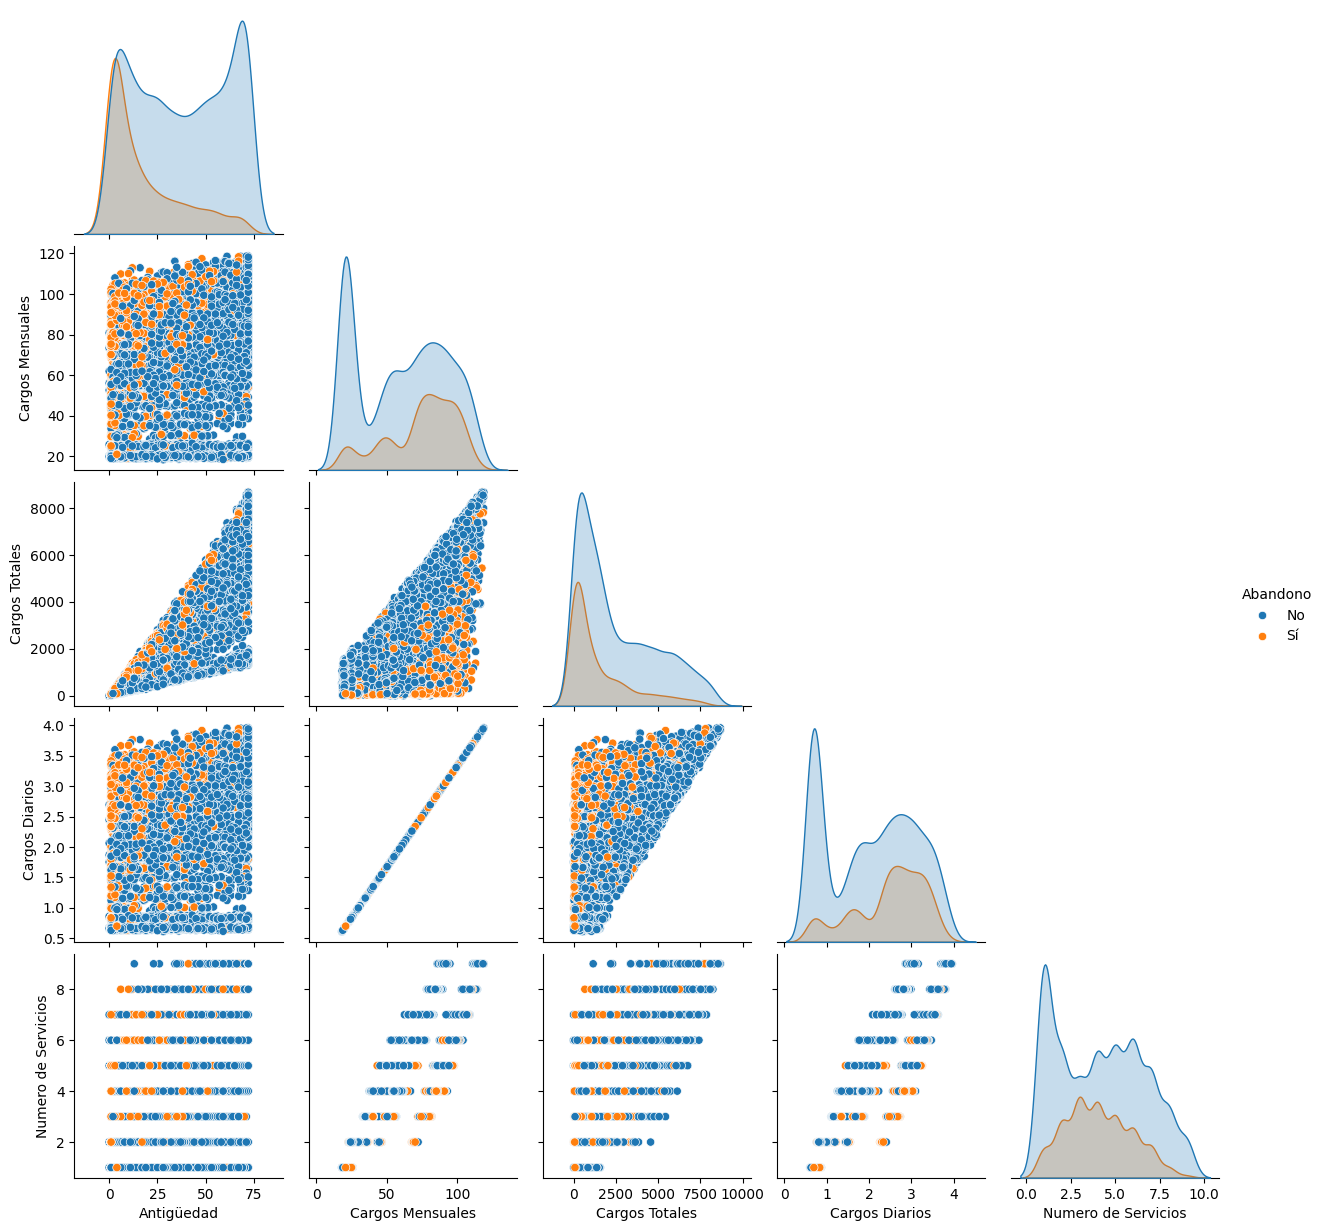

In [42]:
sns.pairplot(datos, hue='Abandono', corner=True)

Mostramos la matriz de correlacion entre variables numericas, incluyendo el numero de sevricios

In [43]:
datos[columnas_numericas+ ['Numero de Servicios']].corr().style.background_gradient(cmap='coolwarm').format(precision=2)

,Cargos Mensuales,Cargos Totales,Cargos Diarios,Antigüedad,Numero de Servicios
Cargos Mensuales,1.00,0.65,1.00,0.25,0.85
Cargos Totales,0.65,1.00,0.65,0.83,0.78
Cargos Diarios,1.00,0.65,1.00,0.25,0.85
Antigüedad,0.25,0.83,0.25,1.00,0.47
Numero de Servicios,0.85,0.78,0.85,0.47,1.00


#### Observaciones

Con este analisis adicional, podemos observar que hay una correlacion entre el abandocno con los cargos (ya sea diarios o mensuales) cuando estos son de aproximadamente \$3.00 al dia, cuando el numero de servicios es superior a 2, y cuando los clientes recien comienzan el contrato.

#📄Informe final

## Introducción

El objetivo de este análisis es comprender a fondo el problema de la evasión de clientes (Abandono) en la empresa de telecomunicaciones. El abandono representa una pérdida significativa de ingresos, por lo que mantener clientes existentes es inportante en el crecimiento y la sostenibilidad de la empresa. A través de este estudio, se quiere identificar los factores que contribuyen a que los clientes abandonen, con el fin de proponer estrategias de retención.

## Limpieza y Tratamiento de Datos



El proceso de limpieza y preprocesamiento de los datos se realizó en varias etapas para asegurar la calidad y la estructura adecuada para el análisis.

**Carga de Datos:**
Los datos se cargaron directamente desde una URL JSON utilizando `pd.read_json()`. Esta función permite importar el archivo de datos directamente desde la fuente en línea, facilitando el acceso y la integración.

**Normalización de Datos:**
Se identificó que la estructura del archivo JSON es anidada, con varias columnas conteniendo diccionarios. Para aplanar esta estructura, se convirtió el DataFrame inicial a una lista de diccionarios con `to_dict(orient='records')` y luego se utilizó `pd.json_normalize()` con `max_level=2`. Esto permitió expandir los diccionarios anidados en columnas separadas, manteniendo la información relevante accesible.

**Manejo de Valores Faltantes:** Durante la exploración inicial, se detectaron valores en blanco en las columnas 'Churn' y 'Charges Total'.
*   Para la columna 'Churn', los registros con valores en blanco fueron eliminados.
*   Para 'Charges Total', se observó que los valores en blanco correspondían a clientes con 'tenure' (antigüedad) de 0, lo que indicaba que aún no se les había generado ningún cargo. Estos valores se imputaron con 0 y posteriormente la columna se convirtió a tipo flotante para permitir operaciones numéricas.

**Renombramiento de Columnas:** Las columnas generadas por la normalización tenían prefijos (`customer.`, `internet.`, `account.`) que se eliminaron y se reemplazaron por nombres más claros y concisos utilizando un diccionario de mapeo. Por ejemplo, `customer.gender` se renombró a `gender` y luego a `Género`.

**Traducción de Valores y conversión de tipo de datos:**
*   Se creó un diccionario de traducción (`traduccion_datos`) para convertir valores binarios ('Yes', 'No') a representaciones numéricas (1, 0) y traducir las otras categorías a español.
*   La columna 'Charges Total' se convirtió explícitamente a tipo flotante después de manejar los valores en blanco.
*En el caso particular de 'Servicio de internet' se conserva el valor de 'No'.

**Cálculo de 'Cargos Diarios':**
Se añadió una nueva columna, 'Cargos Diarios', calculando el cargo diario a partir de los cargos mensuales y  dividiendo por 30 (días en un mes).

## Análisis Exploratorio de Datos




Mediante el análisis exploratorio de datos entendemos la estructura de los datos y vemos patrones para poder explorar las relaciones entre las características de los clientes y la tasa de abandono.
A través de la visualizacion de graficos, buscamos identificar factores que influyen en el abandono.

Se han generado varios gráficos:

*   **Gráfico de barras de distribución de abandono**: Muestra la proporción general de clientes que han abandonado.
*   **Histogramas de acuerdo al tipo de las variables**: Se crearon histogramas para cada conjunto de datosde acuerdo al tipo de informacion (binaria, categórica o numérica), todas comparando la distribución de cada característica con respecto al abandono. Esto nos permite observar cómo las diferentes categorías o rangos de valores en cada característica se correlacionan con la probabilidad de abandono.

Con estos gráficos podemos visualizar directamente qué características tienen un impacto más pronunciado en el abandono de los clientes, facilitando la identificación de segmentos de clientes en riesgo y la formulación de hipótesis para futuras estrategias de retención.

Para las variables categoricas y binarias, realizamos una agrupación de los valores según la columna 'Abandono'
Para cada grupo ('Sí' o 'No' en 'Abandono') y para cada columna categórica seleccionada, calculamos cuántas veces aparece cada valor único y lo convertimos en un porcentaje, y filtramos para los que 'Sí' abandonaron, mostrando la distribución porcentual de cada característica categórica dentro de los grupos de abandono,  y lo ordenamos de mayor a menor porcentaje. De esta manera, las combinaciones de características categóricas que más contribuyen al abandono aparecieron primero.
Finalmente, mostramos el 10% de combinaciones principales de características categóricas y binarias (segunsea el caso) que presentaron los mayores porcentajes de abandono.


## Conclusiones

El análisis exploratorio de datos ha revelado varios puntos clave que pueden ayudar a comprender y mitigar la evasión de clientes.

Primero, la **tasa de abandono general es del 26.54%**, lo cual indica un problema significativo que requiere atención.

**Los clientes con contratos mensuales y pago con cheque electronico tienen una propensión mucho mayor** a abandonar, lo que sugiere que las ofertas a largo plazo o los incentivos para contratos más duraderos podrían ser efectivos.

Esto sugiere la necesidad de incentivar compromisos a largo plazo y revisar posibles puntos de fricción en el proceso de pago con cheque electrónico.

**Los clientes que tienen servicios añadidos (como seguridad online, protección de dispositivo o soporte técnico) muestran una tasa alta de abandono.**

Los usuarios con internet de fibra optica muestran un elevado abandono, especialmente si tambien rechazan los servicios de proteccion complementarios (como seguridad online, protección de dispositivo o soporte técnico).

Esto podría indicar una percepcion de valor insuficiente o problemas de calidad en el servicio de fibra óptica, o una falta de comprensión de los beneficios de los servicios adicionales.

La antigüedad ("Antigüedad") es un factor critico; los **clientes nuevos tienen una alta tasa de abandono**, la cual disminuye conforme el cliente tiene mas tiempo con la empresa, pero se remonta cuando los cargos son superiores a los \$60 mensuales.

En este punto resalta que hay mucho abandono para clientes con cero cargos totales, sugiriendo que hay algun beneficio que se otorga al momento de contratar, pero que no es representativo para mantener el servicio.

Aunque menos pronunciado, segmentos como adultos no mayores, sin pareja, sin dependientes, con servicio telefónico y facturación sin papel, y pago con cheque electronico contribuyen de manera notable al abandono.


## Recomendaciones

Para mitigar el abandono de los clientes se proponen las siguientes estrategias basadas en el análisis realizado:

*   **Fidelización de Contratos a Largo Plazo**: Los clientes con contratos mensuales tienen una tasa de abandono significativamente mayor. Se recomienda implementar programas de incentivos para que los clientes opten por contratos de uno o dos años, ofreciendo descuentos, beneficios exclusivos o servicios adicionales a quienes renueven o se comprometan a plazos más largos.

*   **Mejora de la Experiencia con Fibra Óptica**: Aunque la fibra óptica es un servicio premium, muestra una tasa de abandono más alta. Es crucial investigar las causas subyacentes (problemas de calidad de servicio, soporte, expectativas no cumplidas) y optimizar la experiencia para estos usuarios, garantizando una conexión estable y un soporte técnico eficiente.

*   **Promoción de Servicios de Valor Agregado al servicio de internet.**: Los clientes que no contratan servicios como 'Seguridad Online', 'Copia de Seguridad Online', 'Protección Dispositivo' y 'Soporte Técnico' tienen una mayor propensión al abandono. Se sugiere promover activamente estos servicios como parte de paquetes integrales o como complementos econoimicos.

*   **Atención Especial a Clientes Nuevos y con Bajos Cargos Totales**: Los clientes con baja antigüedad (cercana a cero) son mas propensos a abandonar. Se debe establecer un programa de bienvenida robusto que incluya seguimiento proactivo, asistencia técnica inicial y ofertas personalizadas para asegurar su satisfacción durante los primeros meses.


*   **Optimización de Planes de Precios**: Los 'Cargos Mensuales' elevados están asociados con un mayor churn. Se recomienda revisar la estructura de precios, ofrecer opciones de planes más flexibles o bundles que justifiquen el costo, y comunicar claramente el valor de los servicios para evitar la percepción de sobrecarga.

*   **Revisión del Método de Pago 'Cheque Electrónico'**: Este metodo de pago está correlacionado con una alta tasa de abandono. Podria haber fricciones o problemas asociados con este método. Es aconsejable investigar las causas (por ejemplo, fallos en la transacción, procesos complejos) y buscar soluciones o incentivar el uso de métodos de pago más eficientes y automatizados.
